In [1]:
import torch
import clip
from collections import OrderedDict

# Load base CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, _ = clip.load("ViT-B/32", device=device)

# Load LoRA weights
lora_path = "./lora_modules/vitb32/cub2002011/16shots/seed1/lora_weights.pt"
lora_state = torch.load(lora_path, map_location=device)

# If saved as state_dict only
if "state_dict" in lora_state:
    lora_state = lora_state["state_dict"]

print(f"Loaded LoRA state with {len(lora_state)} tensors.")


Loaded LoRA state with 2 tensors.


In [2]:
for k, v in lora_state.items():
    print(f"\nTop-level key: {k}")
    if isinstance(v, dict):
        for subk, subv in v.items():
            if torch.is_tensor(subv):
                print(f"  {k}.{subk}: {tuple(subv.shape)}, dtype={subv.dtype}")
            else:
                print(f"  {k}.{subk}: {type(subv)}")
    else:
        print(f"  {type(v)}")



Top-level key: weights
  weights.layer_0: <class 'dict'>
  weights.layer_1: <class 'dict'>
  weights.layer_2: <class 'dict'>
  weights.layer_3: <class 'dict'>
  weights.layer_4: <class 'dict'>
  weights.layer_5: <class 'dict'>
  weights.layer_6: <class 'dict'>
  weights.layer_7: <class 'dict'>
  weights.layer_8: <class 'dict'>
  weights.layer_9: <class 'dict'>
  weights.layer_10: <class 'dict'>
  weights.layer_11: <class 'dict'>
  weights.layer_12: <class 'dict'>
  weights.layer_13: <class 'dict'>
  weights.layer_14: <class 'dict'>
  weights.layer_15: <class 'dict'>
  weights.layer_16: <class 'dict'>
  weights.layer_17: <class 'dict'>
  weights.layer_18: <class 'dict'>
  weights.layer_19: <class 'dict'>
  weights.layer_20: <class 'dict'>
  weights.layer_21: <class 'dict'>
  weights.layer_22: <class 'dict'>
  weights.layer_23: <class 'dict'>

Top-level key: metadata
  metadata.r: <class 'int'>
  metadata.alpha: <class 'int'>
  metadata.encoder: <class 'str'>
  metadata.params: <class '

In [3]:
for lname, ldict in lora_state["weights"].items():
    print(f"\nLayer: {lname}")
    for subk, subv in ldict.items():
        if isinstance(subv, dict):
            for kk, vv in subv.items():
                if torch.is_tensor(vv):
                    print(f"  {lname}.{subk}.{kk}: {tuple(vv.shape)}")
        elif torch.is_tensor(subv):
            print(f"  {lname}.{subk}: {tuple(subv.shape)}")



Layer: layer_0
  layer_0.q_proj.w_lora_A: (2, 512)
  layer_0.q_proj.w_lora_B: (512, 2)
  layer_0.k_proj.w_lora_A: (2, 512)
  layer_0.k_proj.w_lora_B: (512, 2)
  layer_0.v_proj.w_lora_A: (2, 512)
  layer_0.v_proj.w_lora_B: (512, 2)

Layer: layer_1
  layer_1.q_proj.w_lora_A: (2, 512)
  layer_1.q_proj.w_lora_B: (512, 2)
  layer_1.k_proj.w_lora_A: (2, 512)
  layer_1.k_proj.w_lora_B: (512, 2)
  layer_1.v_proj.w_lora_A: (2, 512)
  layer_1.v_proj.w_lora_B: (512, 2)

Layer: layer_2
  layer_2.q_proj.w_lora_A: (2, 512)
  layer_2.q_proj.w_lora_B: (512, 2)
  layer_2.k_proj.w_lora_A: (2, 512)
  layer_2.k_proj.w_lora_B: (512, 2)
  layer_2.v_proj.w_lora_A: (2, 512)
  layer_2.v_proj.w_lora_B: (512, 2)

Layer: layer_3
  layer_3.q_proj.w_lora_A: (2, 512)
  layer_3.q_proj.w_lora_B: (512, 2)
  layer_3.k_proj.w_lora_A: (2, 512)
  layer_3.k_proj.w_lora_B: (512, 2)
  layer_3.v_proj.w_lora_A: (2, 512)
  layer_3.v_proj.w_lora_B: (512, 2)

Layer: layer_4
  layer_4.q_proj.w_lora_A: (2, 512)
  layer_4.q_proj.w_l

In [3]:
"""

"""

import torch
import clip
from pathlib import Path
from torchvision import datasets

# ============================================================
# 1. Load base CLIP and LoRA checkpoint
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

model, _ = clip.load("ViT-B/32", device=device)
print("Base CLIP loaded.")

lora_path = Path("/home/sunayana/Documents/Concept_LoRA/lora_weights/vitb32/oxford_pets/16shots/seed1/lora_weights.pt")
lora_state = torch.load(lora_path, map_location=device)
layers = lora_state["weights"]
meta = lora_state["metadata"]

r, alpha = meta["r"], meta["alpha"]
scale = alpha / r
print(f"LoRA rank={r}, alpha={alpha}, scale={scale}, layers={len(layers)}")


# ============================================================
# 2. Merge helper function
# ============================================================
def apply_lora_to_block(block, lora_dict, scale):
    """
    Merges LoRA weights into q, k, v projection layers of a transformer block.
    block: CLIP transformer block
    lora_dict: dict of LoRA matrices for that block (A/B pairs)
    scale: scaling factor (alpha / r)
    """
    for proj_name in ["q_proj", "k_proj", "v_proj"]:
        try:
            A = lora_dict[f"{proj_name}.w_lora_A"].to(block.attn.in_proj_weight.device)
            B = lora_dict[f"{proj_name}.w_lora_B"].to(block.attn.in_proj_weight.device)
        except KeyError:
            print(f"Skipping {proj_name} — not found in LoRA dict")
            continue

        # Convert LoRA weight shapes (r, d) and (d, r) to (d, d)
        delta_w = scale * (B @ A)

        # Add LoRA update to base projection weight
        # Depending on your CLIP-LORA repo, projection weights may be combined (in_proj_weight)
        if hasattr(block.attn, "in_proj_weight"):  
            # Split the combined qkv weight and add to each section
            w = block.attn.in_proj_weight.data
            d = w.shape[1]
            head = d // 3
            if proj_name == "q_proj":
                w[:head, :] += delta_w
            elif proj_name == "k_proj":
                w[head:2*head, :] += delta_w
            elif proj_name == "v_proj":
                w[2*head:, :] += delta_w
        elif hasattr(block.attn, proj_name):
            block.attn.__getattr__(proj_name).weight.data += delta_w
        else:
            print(f"Could not locate {proj_name} weight in block.")


# ============================================================
# 3. Apply LoRA updates to both encoders
# ============================================================

# --- Text encoder: layers 0–11 ---
for i in range(12):
    lora_dict = layers[f"layer_{i}"]
    apply_lora_to_block(model.transformer.resblocks[i], lora_dict, scale)
print("Merged LoRA into text encoder.")

# --- Vision encoder: layers 12–23 ---
for i in range(12, 24):
    lora_dict = layers[f"layer_{i}"]
    apply_lora_to_block(model.visual.transformer.resblocks[i - 12], lora_dict, scale)
print("Merged LoRA into vision encoder.")


# ============================================================
# 4. Save merged model
# ============================================================
save_path = Path("clip_vitb32_pets_lora_merged.pt")
torch.save(model.state_dict(), save_path)
print(f"Merged model saved to {save_path.resolve()}")


Base CLIP loaded.
LoRA rank=2, alpha=1, scale=0.5, layers=24
Skipping q_proj — not found in LoRA dict
Skipping k_proj — not found in LoRA dict
Skipping v_proj — not found in LoRA dict
Skipping q_proj — not found in LoRA dict
Skipping k_proj — not found in LoRA dict
Skipping v_proj — not found in LoRA dict
Skipping q_proj — not found in LoRA dict
Skipping k_proj — not found in LoRA dict
Skipping v_proj — not found in LoRA dict
Skipping q_proj — not found in LoRA dict
Skipping k_proj — not found in LoRA dict
Skipping v_proj — not found in LoRA dict
Skipping q_proj — not found in LoRA dict
Skipping k_proj — not found in LoRA dict
Skipping v_proj — not found in LoRA dict
Skipping q_proj — not found in LoRA dict
Skipping k_proj — not found in LoRA dict
Skipping v_proj — not found in LoRA dict
Skipping q_proj — not found in LoRA dict
Skipping k_proj — not found in LoRA dict
Skipping v_proj — not found in LoRA dict
Skipping q_proj — not found in LoRA dict
Skipping k_proj — not found in LoRA d

In [2]:
import torch

ckpt_path="/home/sunayana/Documents/Concept_LoRA/Discover-then-Name/lora_and_cubclf.pth"

ckpt = torch.load(ckpt_path, map_location="cpu")
for k, v in ckpt.items():
    if torch.is_tensor(v):
        print(f"{k}: {tuple(v.shape)}, dtype={v.dtype}")
    else:
        print(f"{k}: {type(v)}")

classifier.0.weight: (256, 512), dtype=torch.float32
classifier.0.bias: (256,), dtype=torch.float32
classifier.2.weight: (200, 256), dtype=torch.float32
classifier.2.bias: (200,), dtype=torch.float32


Plot saved as recreated_plot_final.png


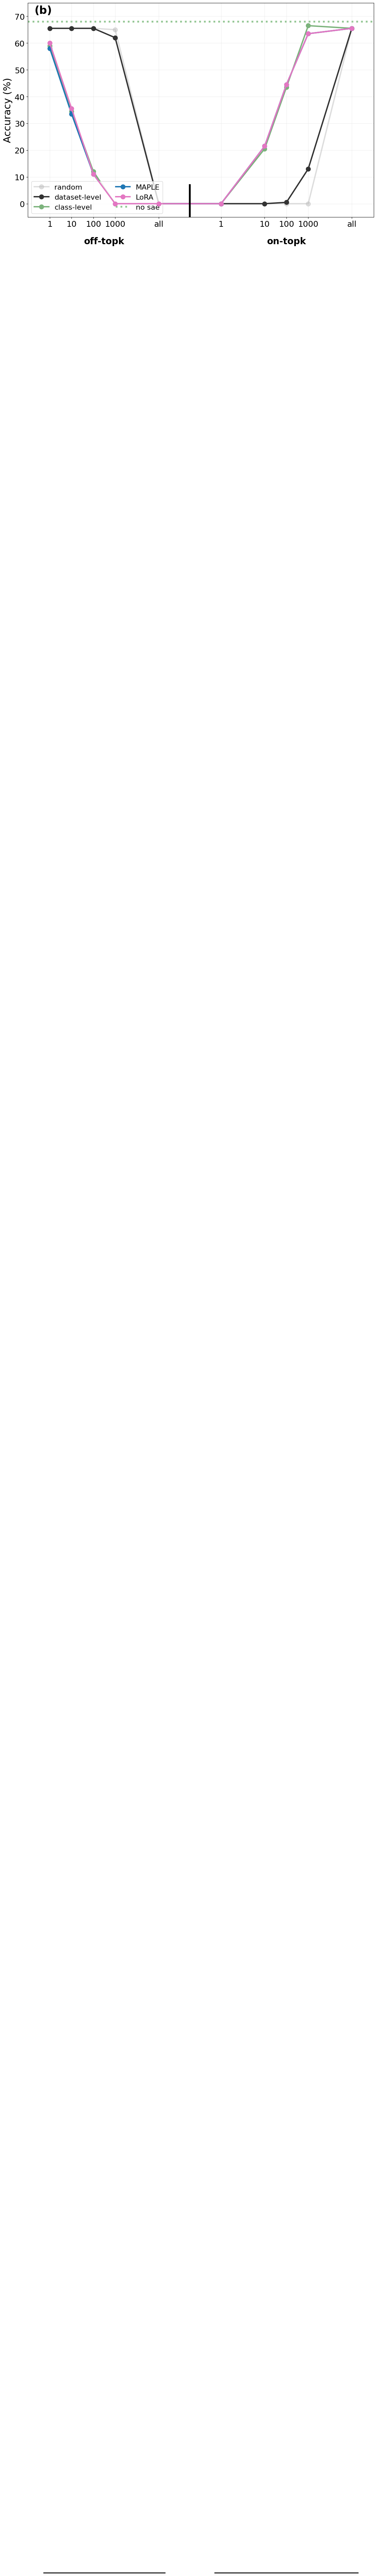

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Define x-positions to make the "top k" (1, 10, 100, 1000) closer together
# spacing: 0, 0.7, 1.4, 2.1 then a gap to 'all' at 4
x_off = [0, 0.7, 1.4, 2.1, 4.0]
x_on = [5.6, 7.5, 8.2, 8.9, 9.6] # Wait, let's keep it simpler for alignment
# Better: [0, 0.7, 1.4, 2.1, 3.5] [5.5, 6.9, 7.6, 8.3, 9.0]
x_indices = [0, 0.7, 1.4, 2.1, 3.5, 5.5, 6.9, 7.6, 8.3, 9.7]
x_labels = ['1', '10', '100', '1000', 'all', '1', '10', '100', '1000', 'all']

# Data estimation (y-values)
no_sae_val = 68

# Original lines
random_data = [65.5, 65.5, 65.5, 65, 0, 0, 0, 0, 0, 65.5]
dataset_level = [65.5, 65.5, 65.5, 62, 0, 0, 0, 0.5, 13, 65.5]
class_level = [59, 34.5, 12, 0, 0, 0, 20.5, 43.5, 66.5, 65.5]

# MAPLE (coinciding with green, mark it blue)
maple_data = [58, 33.5, 11, 0, 0, 0, 21.5, 44.5, 63.5, 65.5]

# LoRA (just above MAPLE)
lora_data = [60, 35.5, 11, 0, 0, 0, 21.5, 44.5, 63.5, 65.5]
# Actually LoRA should be "above" in the sense of higher accuracy/recovery


%config InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight', 'pad_inches': 0}

# Colors
color_no_sae = '#94C794'
color_random = '#BDBDBD'
color_dataset = '#333333'
color_class = '#7CB37C'
color_maple = '#1f77b4' # Blue
color_lora = '#e377c2' # Pink/Purple

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 18, 'font.family': 'sans-serif'})

# Grid
plt.grid(True, linestyle='-', alpha=0.6, color='#E0E0E0', zorder=0)

# Horizontal baseline
plt.axhline(y=no_sae_val, color=color_no_sae, linestyle=':', linewidth=4, label='no sae', zorder=1)

# Plot lines
plt.plot(x_indices, random_data, marker='o', markersize=10, color=color_random, linewidth=3, alpha=0.5, label='random', zorder=2)
plt.plot(x_indices, dataset_level, marker='o', markersize=10, color=color_dataset, linewidth=3, label='dataset-level', zorder=3)
plt.plot(x_indices, class_level, marker='o', markersize=10, color=color_class, linewidth=3, label='class-level', zorder=4)

# New lines
plt.plot(x_indices, maple_data, marker='o', markersize=10, color=color_maple, linewidth=3, label='MAPLE', zorder=5)
plt.plot(x_indices, lora_data, marker='o', markersize=10, color=color_lora, linewidth=3, label='LoRA', zorder=6)

# Vertical line separator (shorter, as in original)
plt.axvline(x=(x_indices[4] + x_indices[5])/2, color='black', linewidth=4, ymin=0, ymax=0.15, zorder=10)

# Labels
plt.ylabel('Accuracy (%)', fontsize=22)
plt.xticks(x_indices, x_labels, fontsize=18)
plt.yticks(range(0, 71, 10), fontsize=18)
plt.ylim(-5, 75)

# Legends
handles, labels = plt.gca().get_legend_handles_labels()
# Sort: random, dataset, class, MAPLE, LoRA, no sae
order = [1, 2, 3, 4, 5, 0]
plt.legend([handles[i] for i in order], [labels[i] for i in order], loc='lower left', frameon=True, fontsize=16, ncol=2)

# Subplot labels
plt.text(-0.5, 71, '(b)', fontweight='bold', fontsize=24)

# Phase labels
mid_off = (x_indices[0] + x_indices[4]) / 2
mid_on = (x_indices[5] + x_indices[9]) / 2
plt.text(mid_off, -15, 'off-topk', ha='center', fontweight='bold', fontsize=20)
plt.text(mid_on, -15, 'on-topk', ha='center', fontweight='bold', fontsize=20)

# Grouping lines
plt.plot([x_indices[0]-0.2, x_indices[4]+0.2], [-11, -11], color='black', linewidth=2, transform=plt.gca().get_xaxis_transform(), clip_on=False)
plt.plot([x_indices[5]-0.2, x_indices[9]+0.2], [-11, -11], color='black', linewidth=2, transform=plt.gca().get_xaxis_transform(), clip_on=False)

plt.tight_layout(pad=0)
plt.savefig('recreated_plot_final.png', bbox_inches='tight', pad_inches=0)
print("Plot saved as recreated_plot_final.png")